# Basics

This notebook introduces the basic structure of pointclouds and their most common attributes. It covers how pointcloud data is represented, loaded, visualized, and inspected, and  introduces simple geometric properties such as centroids and bounding boxes. These fundamental concepts form the basis for more advanced processing techniques explored in the following notebooks.

In [1]:
# Necessary imports
import sys
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

sys.path.append("./utils")
from plot_utils import cuboid_to_poly3D

## What is a pointcloud?

A pointcloud generally refers to a set of points defined in a geometric space. In the context of this notebook and the following ones, this space is three-dimensional, and each point is described by its coordinates $(x,y,z)$. A pointcloud may thus be seen as a **discrete representation of a shape or object, where geometry is captured by sampling points on its surface**. In contrast to continuous representations (e.g., parametric surfaces), this sampling provides only a finite approximation of the underlying geometry.

Formally, a pointcloud can be represented as a set of points:
\begin{equation*}
    P = \{p_{0}, p_{1}, ..., p_{n-1} \}
\end{equation*}
where each point $p_{i} \in \mathbb{R}^{3}$ is defined by its coordinates $p_{i} = (x_{i}, y_{i}, z_{i})$. 

This mathematical description emphasizes that a pointcloud is fundamentally an unordered set of samples in 3D space. So, unlike other representations such as meshes or parametric surfaces, pointcloud are:

* **Unstructured** (no connectivity is defined between points)
* **Unordered** (the ordering of points itself carries no information)

Pointclouds are widely used in domains involving 3D data acquisition and analysis, such as engineering (reverse engineering and inspection), autonomous systems (perception for robots or self-driving vehicles), and geographic information systems (terrain mapping). Their properties are strongly influenced by the acquisition process. As a result, pointclouds are often:

* **Noisy** (measurement errors)
* **Irregularly sampled** (non-uniform density)
* **Incomplete** (occlusions or limited sensor coverage)

These characteristics make point clouds both flexible and challenging to process.

## Loading

Pointclouds are stored using a variety of file formats, depending on acquisition systems, processing software, as well as data size and content.

**The simplest formats are ASCII formats**, with extensions such as *.txt*, *.pts*, and *.xyz*. These are plain text files in which values are separated by whitespace or commas, and each line corresponds to a point. ASCII formats are easy to read and edit, but not memory-efficient, making them best suited for small to medium-sized pointclouds (typically up to a few hundred thousand points).

**More efficient formats rely on binary encoding** to reduce storage size and improve input/output (I/O) performance, making them better suited for large-scale pointclouds. The most common open formats for storing 3D pointclouds include:

* **PLY** (developed at Stanford, also supporting ASCII), flexible and widely used in research
* **PCD** (native of PCL, the Point Cloud Library), flexible and widely used in robotics
* **LAS** and LAZ (ASPRS standard), standard formats for LiDAR data, commonly used in geospatial applications
* **E57** (ASTM standard), designed for efficient storage and interoperability

For the sake of simplicity, this notebook and the following ones use an ASCII-based format, with points coordinates separated by whitespaces.

Such files can be easily loaded using Python and its most commonly used numerical library ```numpy```.

In [2]:
# Load the pointcloud data from the .xyz file with a simple line of code
points = np.loadtxt("./data/stanford_bunny_simple.xyz")
print("Here is the content of our pointcloud:\n", points)
print("Its shape is:", points.shape)

Here is the content of our pointcloud:
 [[-25.5861 106.9803  42.684 ]
 [-30.1628  93.312  -47.9823]
 [ -8.5167 100.3486  73.1544]
 ...
 [ 39.3746 100.979   -1.1485]
 [-54.9932  84.2855 -32.3682]
 [-77.221  104.7658 -26.0204]]
Its shape is: (4096, 3)


Here, data are stored in a Numpy array, which is better suited for numerical operations than than a simple list. Points are usually listed *row-wise* (one point per line), resulting in a vector of shape $(n, 3)$ ($n$ being the total number of points), although the contrary (i.e., *column-wise*) is also found. Points are defined by their cartesian coordinates, meaning their position from the origin according to the $x$, $y$, and $z$ axes.

The loaded pointcloud is derived from the *Stanford bunny*, which is a popular test model used in computer graphics. The original model was obtained by scanning a ceramic figurine of a rabbit. It is considered a simple model by today's standards, in terms of both size and geometric complexity. Our pointcloud is an even more simplified version to facilitate manipulation and visualization.

## Visualizing

Visualizing a pointcloud is often the simplest step to gain an intuitive understanding of its geometry. Again, many options are available, depending on data format, size and content.

The simplest approach consists in representing each point with a scatter plot, using tools for data visualization. This notebook and the following ones use ```matplotlib```, which is among the most commonly used libraries in Python.

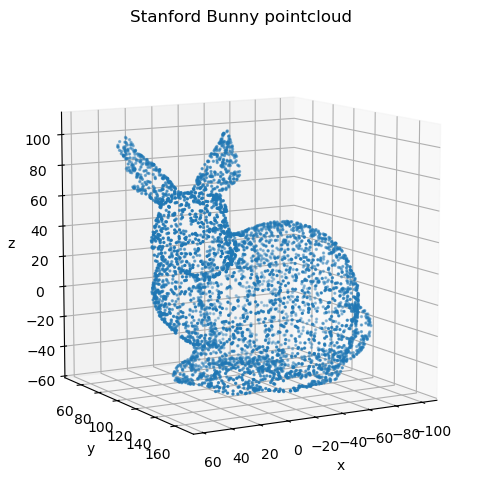

In [3]:
# Visualize the pointcloud with a simple 3D scatter plot using Matplotlib
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(projection="3d")
# x, y, and z coordinates are stored in the first, second, and third columns
ax.scatter(points[:, 0], points[:, 1], points[:, 2],
           s=2.) # makes points smaller for better visualization
# Axis labels
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
# Ensure equal scaling along all axes (avoid distortion)
ax.set_box_aspect([1, 1, 1])
# Adjust the view angle for better visualization
ax.view_init(elev=10, azim=60)
# Set title and show the plot
ax.set_title("Stanford Bunny pointcloud")
plt.show()


It is important to keep in mind that pointclouds are often large, sparse, and irregularly sampled, which may affect both rendering performance and visual clarity.

For larger pointclouds (typically containing tens of thousands of points or more) and more interactive and advanced visualization (e.g., with shading), dedicated libraries, such as ```open3D```, or software, such as CloudCompare, are generally preferred.

## Inspecting

As seen before, each point $p_{i}$ of the pointcloud $P$ is defined by *a minima* three coordinates $(x_{i}, y_{i}, z_{i})$, which describe its position in space. However, it is common for points to carry additional information, called *point attributes* (distinct from metadata). These attributes may be given directly by the acquisition system, or computed afterwards.

Among the most popular attributes are:

* **Intensity**, which measures the strength of the returned signal (typically obtained from LiDAR systems)
* **Colors** (typically obtained from imaging devices)
* **Normals**, which describe the local orientation of the surface (usually estimated)
* **Scalar fields**, which represent any per-point quantity

Colors, normals and scalar fields are described more in details below.

In practice, a pointcloud with attributes is represented by an array of shape $(n, d)$, with $n$ the number of points and $d$ the number of attributes per point (including its spatial coordinates). The $(n ,d)$ array is usually split into dedicated arrays (e.g., spatial coordinates, normals, colors) for clarity and ease of manipulation.

Inspection also provides an opportunity to perform basic checks, such as searching for invalid data.

In [4]:
# Load the pointcloud data with additional attributes (colors, normals, etc.)
data = np.loadtxt("./data/stanford_bunny_custom.xyz")
print("Shape of our data:", data.shape)
# Basic check for inconsistencies or missing values (NaN)
print("Number of NaN values:", np.isnan(data).sum())
# Split the data into separate arrays for points, colors, scalars, and normals
points = data[:, :3]
colors = data[:, 3:6]
scalars = data[:, 6:9]
normals = data[:, 9:12]

Shape of our data: (4096, 12)
Number of NaN values: 0


### Colors

Color attributes account for the visual appearance of each point. They may be acquired directly using imaging sensors or obtained by projecting images onto the pointcloud. In the first case, it is important to keep in mind that **colors may vary to the acquisition conditions** (the lighting in particular).

Colors are typically represented with **the RGB color model, that defines a color as an addition of the red, green and blue** primary colors. A RGB color vector associated to a point has three components, noted R, G, and B, with values generally ranging from 0 to 255 (integers) or from 0 to 1 (floats). 

This gives a vector of shape $(n, 3)$, with $n$ being the total number of points.

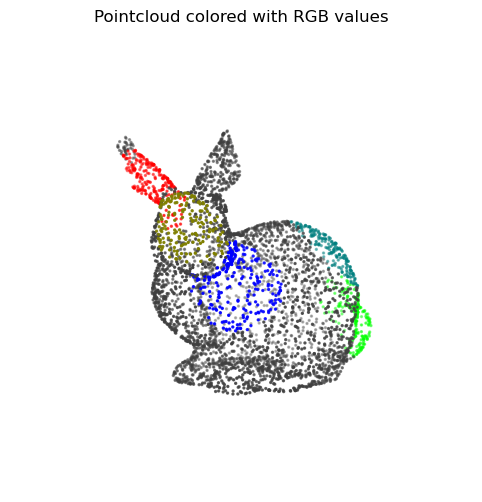

In [5]:
# Plot the pointcloud colored with RGB values
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")
# Add colors to the scatter plot 
ax.scatter(points[:, 0], points[:, 1], points[:, 2], s=2.,
           c=colors) # RGB values need to be normalized in Matplotlib
ax.set_axis_off() # Hide axes for better visualization
ax.set_box_aspect([1, 1, 1]) # Ensure equal aspect ratio
ax.view_init(elev=10, azim=60) # Adjust the view angle
ax.set_title("Pointcloud colored with RGB values")
plt.show()


### Normals

Normals describe the **local orientation of the surface at each point**. A normal associated with a point is typically assumed to be perpendicular to the underlying surface and oriented outward. Normals may be provided directly by the acquisition device, but are more commonly estimated from the pointcloud geometry (see the notebook on normals and curvatures).

A normal vector $n_i$ associated to a point $p_i$ has three components, noted $n_{i,x}$, $n_{i,y}$, and $n_{i,z}$. It is generally a unit vector, which means that its norm is equal to one: $||n_i|| = 1$.

In practice, similar to colors, normals are stored in an array of shape $(n, 3)$, where $n$ is the total number of points.

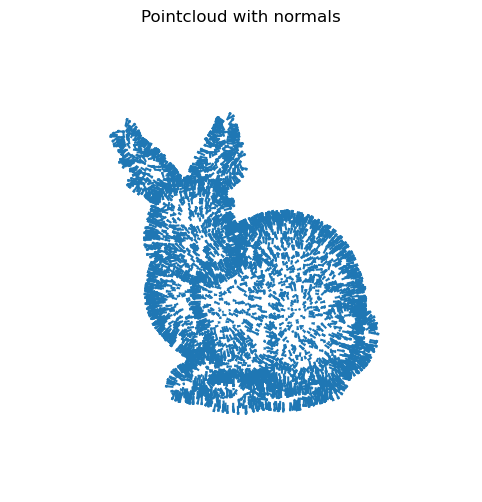

In [6]:
# Plot normals
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")
ax.quiver(points[:, 0], points[:, 1], points[:, 2], # points
          normals[:, 0], normals[:, 1], normals[:, 2], # normals
          length=5.) # make normals a little bigger for visualization purposes
ax.set_box_aspect([1, 1, 1]) # Ensure equal aspect ratio
ax.view_init(elev=10, azim=60) # Adjust the view angle
ax.set_axis_off() # Hide axes for better visualization
ax.set_title("Pointcloud with normals")
plt.show()


Normals play a central role in many pointcloud processing algorithms, but are also used for visualization and rendering purposes. For instance, computing the angle between an incident light direction and normal vectors provides a simple model for simulating light reflection on a surface, as shown below.

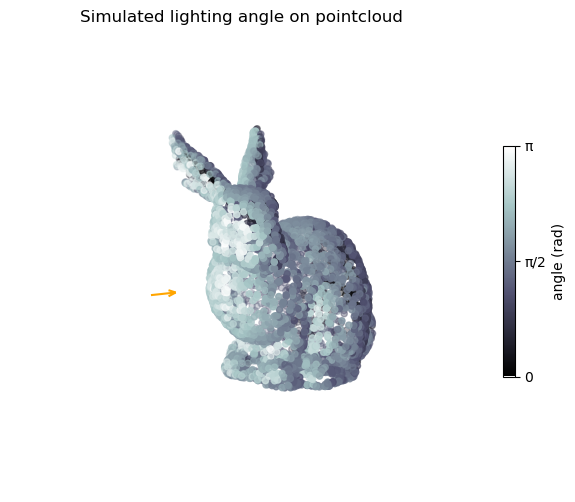

In [7]:
# Incident ray (unit vector giving the direction of light)
v_dir = np.array([-1., 0., 0.])
# Magnitude and location of the light source (for visualization purposes)
v_mag =  25.
v_loc = np.array([120., 120., 10.])

# Angle between the normals and the incident ray
theta = np.arccos(normals @ v_dir)

# Plot the pointcloud colored with the lighting angle
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")
p = ax.scatter(points[:, 0], points[:, 1], points[:, 2],
          c=theta, # color the points according to the angle
          cmap="bone" # use a black-and-white colormap
    )
ax.quiver(v_loc[0], v_loc[1], v_loc[2], # location of the light source
          v_dir[0], v_dir[1], v_dir[2], # direction of the incident ray
          length=v_mag, # length of the arrow representing the incident ray
          color='orange')
cbar = fig.colorbar(p, shrink=0.5) 
cbar.set_label('angle (rad)')
cbar.set_ticks([0., np.pi/2, np.pi]) # Tick positions at 0, π/2, and π
cbar.set_ticklabels(['0', 'π/2', 'π']) # Tick labels to display in terms of π
ax.set_box_aspect([1, 1, 1]) # Ensure equal aspect ratio
ax.view_init(elev=10, azim=60) # Adjust the view angle
ax.set_axis_off() # Hide axes for better visualization
ax.set_title("Simulated lighting angle on pointcloud")
plt.show()


### Scalar fields

In general terms, a scalar field is a function associating a single number to every point in a space. Here, scalar fields simply designate **values associated with a point**. These values may represent a wide range of quantities, such as density or curvature.

Scalar fields are sometimes given by the acquisition device or may result of a calculation. In practice, a scalar field is used to associate any quantity of interest with the pointcloud. There may be several scalar fields associated with a given pointcloud.

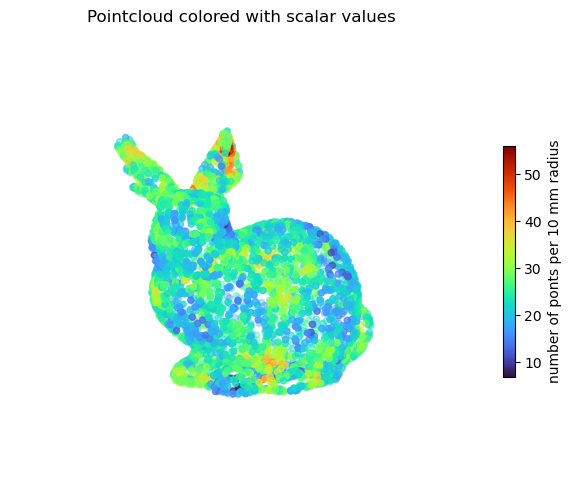

In [8]:
# Scalar field representing the number of points within a 10 mm radius
N_R10 = scalars[:, 2]

# Plot the pointcloud colored with scalar values
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")
p = ax.scatter(points[:, 0], points[:, 1], points[:, 2],
           c=N_R10, cmap="turbo")
cbar = fig.colorbar(p, shrink=0.5)
cbar.set_label('number of ponts per 10 mm radius')
ax.set_box_aspect([1, 1, 1]) # Ensure equal aspect ratio
ax.view_init(elev=10, azim=60) # Adjust the view angle
ax.set_axis_off() # Hide axes for better visualization
ax.set_title("Pointcloud colored with scalar values")
plt.show()


## Geometric properties

The following paragraphs detail simple geometric properties of the pointcloud. These properties are computed directly from the point coordinates and form the basis for more advanced processing.

### Centroid

The centroid of a pointcloud is the average position of all its points. It provides a simple estimate of the center of mass of the object. Its formula is simply:

\begin{equation*}
    \bar{p} = \frac{1}{n} \sum^{n-1}_{i=0} p_i
\end{equation*}

The centroid is often used for centering or normalizing a pointcloud prior to further processing.

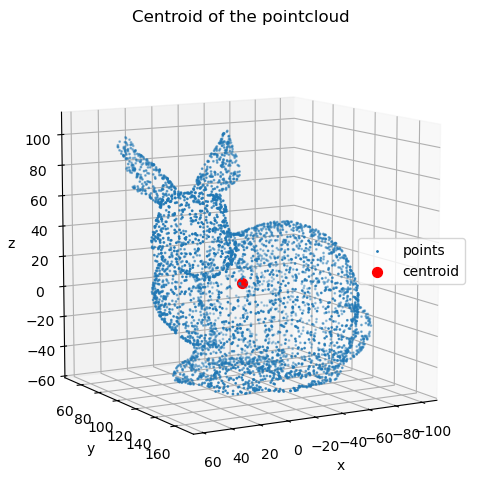

In [9]:
# Compute the centroid of the pointcloud
centroid = points.mean(axis=0)

# Show the centroid on the plot
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(points[:, 0], points[:, 1], points[:, 2], label="points", s=1.)
ax.scatter(centroid[0], centroid[1], centroid[2], c='r', label="centroid", s=50.)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
ax.legend(loc="right")
ax.set_box_aspect([1, 1, 1]) # Ensure equal aspect ratio
ax.view_init(elev=10, azim=60) # Adjust the view angle
ax.set_title("Centroid of the pointcloud")
plt.show()

### Bounding box

The axis-aligned bounding box (AABB) defines the smallest box, aligned with the coordinate axes, that contains all points. It is usually described by two vectors, the minimum coordinates and the maximum coordinates, also called the lower and upper bounds:

\begin{equation*}
    upper = \max_i(p_i) \qquad lower = \min_i(p_i)
\end{equation*}

where the minimum and maximum are taken component-wise over all points.

The bounding box provides a quick approximation of the location and size of the pointcloud (and the sampled objects).

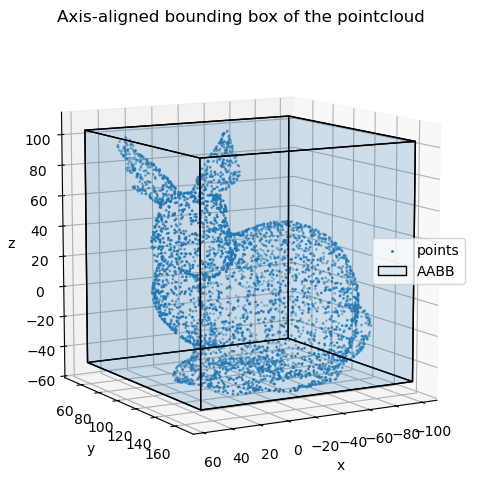

In [10]:
# Compute the axis-aligned bounding box (AABB)
bbox_lower = points.min(axis=0)
bbox_upper = points.max(axis=0)

# Show the bounding box on the plot
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(points[:, 0], points[:, 1], points[:, 2], s=1, label="points")
# Plot the bounding box
bbox = cuboid_to_poly3D(bbox_lower, bbox_upper - bbox_lower) # custom function
pc = Poly3DCollection(bbox, edgecolor="k", alpha=0.1, label="AABB")
ax.add_collection3d(pc)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
ax.legend(loc="right")
ax.set_box_aspect([1, 1, 1]) # Ensure equal aspect ratio
ax.view_init(elev=10, azim=60) # Adjust the view angle
plt.title("Axis-aligned bounding box of the pointcloud")
plt.show()

### Extent

The extent of the pointcloud corresponds to its size along each coordinate axis. 
It can be computed as the difference between the maximum and minimum point coordinates:

\begin{equation*}
    ext = \max_i(p_i) - \min_i(p_i)
\end{equation*}

where the minimum and maximum are taken component-wise over all points.

This quantity is useful for understanding the scale of the data and for defining normalization or discretization strategies.


In [11]:
# Compute the extent
extent = np.ptp(points, axis=0)
with np.printoptions(precision=1, suppress=True): # for better readability
    print("Extent of the pointcloud (size along x, y, z):", extent)

Extent of the pointcloud (size along x, y, z): [155.6 119.4 153.4]


## Wrapping up

You should now have a better grasp of what a pointcloud is, how it is represented, and how to inspect and manipulate it in practice.

A key takeaway is that pointclouds represents a shape in a quite simple and flexible way, that is as a set of points in a 3D space, possibly enriched with additional attributes such as normals or colors. This representation is inherently **unordered** and **discrete**. It is also important to remember that real-world pointclouds are typically **noisy**, **irregularly sampled**, and often **incomplete**.

From a pratical perspective,  pointclouds can be handled efficiently using standard numerical tools such as Numpy. Relying on vectorized operations is essential for keeping the code both concise and fast. As a rule of thumb, explicit Python loops should be avoided whenever possible. On a modern marchine (e.g., a laptop with a recent CPU and with several gigabytes of RAM), pointclouds containing several million points can be loaded and processed within reasonable time (in under a minute) for basic operations.

However, as pointclouds grow larger, dedicated visualization tools quickly become necessary. General‑purpose plotting libraries like Matplotlib remain usable only for relatively small datasets (up to tens of thousands of points). Larger pointclouds require specialized software optimized for 3D visualization.